# makemore: part 3

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [9]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [10]:
len(words)

32033

In [11]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [12]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

# play with the weight initialization constnat 

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) * 0.2 # pytorch kaiming normal 
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # init logit weights
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

# dead neuron test
# parameters = [C, W1, b1, W2, b2]

parameters = [C, W1, W2, b1, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(20000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1  + b1 # hidden layer pre-activation
                        # notice b1 is meaned in bnmeani
                        # bias before batch norm is useless, verify by printing b1

  # BatchNorm layer
  # we want to use batchnorm to control the statistics of activations
  # its common to sprinkle bn after mutiplicative and convolutional layers
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # here is where we use batch bias
                                                           # instead of b1, remember to include in param to grad
  # when inferencing, bnmean/std_running of the hidden states
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------

  # Ideally for tanh, a gaussian would be nice because less on the dead tails
  # given hpreact, center around mean, scale to unit variance
  # set bngain and bnbias to normalize
  # Non-linearity
  h = torch.tanh(hpreact)  # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # check input layer deadspots with break
  # check running std and mean is initialized correctly for inference 
  break
  

      0/ 200000: 3.3147


In [15]:
b1.grad

tensor([ 3.4925e-10, -6.9849e-10,  9.3132e-10, -1.1642e-10, -1.1642e-10,
         2.3283e-10, -1.1642e-10,  6.9849e-10, -1.1642e-10,  1.4552e-10,
         1.1642e-10,  2.3283e-10, -6.9849e-10,  4.3656e-10, -1.1642e-10,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  1.1642e-10,  1.1642e-10,
         4.6566e-10,  5.8208e-11, -1.1642e-10,  2.3283e-10,  4.6566e-10,
         0.0000e+00,  1.6298e-09,  3.4925e-10,  3.4925e-10,  0.0000e+00,
         0.0000e+00, -1.1642e-10, -2.3283e-10, -1.4552e-11,  1.1642e-10,
        -4.6566e-10,  3.4925e-10,  1.0186e-10, -1.1642e-10,  1.1642e-10,
         4.6566e-10, -4.6566e-10,  5.0932e-11, -2.3283e-10,  1.1642e-09,
        -8.1491e-10, -2.9104e-10, -2.3283e-10,  0.0000e+00,  9.8953e-10,
         6.9849e-10, -1.3388e-09, -1.1642e-10,  1.7462e-10, -5.5297e-10,
        -4.6566e-10,  1.6298e-09,  8.7311e-11,  3.4925e-10, -4.6566e-10,
        -1.1642e-10,  8.7311e-10,  1.1642e-10,  2.3283e-10,  0.0000e+00,
         4.6566e-10, -1.8917e-10, -9.3132e-10, -1.1

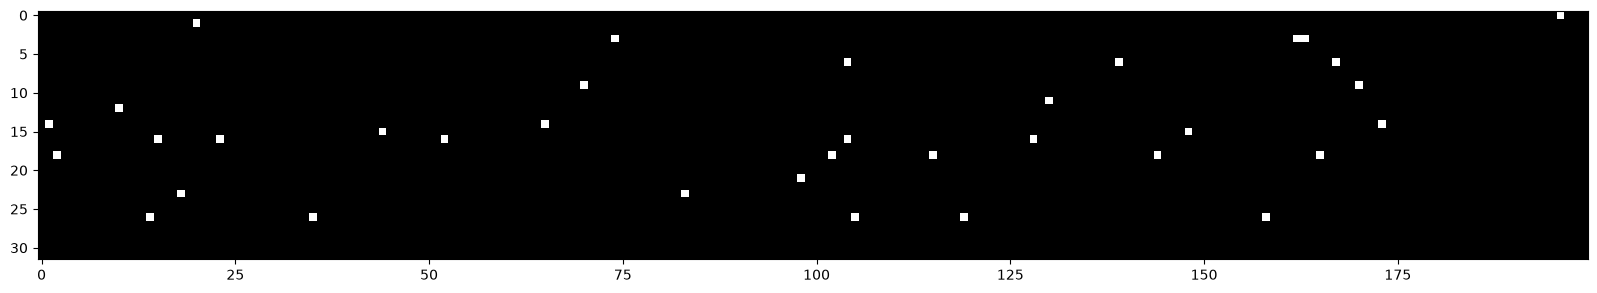

In [16]:
# verify hidden layer with different weight initialization constnat 
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest')

In [17]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [18]:
# check bmean and brunning mean should be similar
print(bnmean)

tensor([[-0.1166, -0.0410, -0.1919,  0.1594,  0.1431,  0.1298,  0.2292, -0.1553,
         -0.1047,  0.0819, -0.1041, -0.2167,  0.0352,  0.0277, -0.0077,  0.0470,
          0.1249, -0.1842, -0.0939,  0.2214,  0.0607, -0.1189,  0.0693,  0.0970,
          0.0573,  0.0869,  0.0803,  0.0097,  0.0029,  0.1653, -0.0605, -0.1014,
         -0.0029,  0.0425, -0.0998, -0.1112, -0.0519, -0.1049, -0.0720,  0.0781,
         -0.0082, -0.2038, -0.1477, -0.0714,  0.0294, -0.0489,  0.0090, -0.0609,
          0.1192,  0.2293,  0.0334, -0.0047,  0.2242,  0.1638,  0.0980, -0.1477,
         -0.0308,  0.2018,  0.2030, -0.0706, -0.0613,  0.0922,  0.0659, -0.0087,
          0.1729,  0.0878,  0.1414,  0.0081, -0.0861, -0.0023, -0.0371,  0.1434,
          0.1416, -0.1309, -0.2616,  0.0062,  0.1502, -0.0508, -0.0164,  0.0114,
          0.0772,  0.1922,  0.1334,  0.1101,  0.0665, -0.0389, -0.1270, -0.0038,
          0.0558, -0.0896,  0.0988,  0.1161, -0.0894, -0.0253, -0.0559, -0.1097,
         -0.1092, -0.0576,  

In [19]:
print(bnmean_running)

tensor([[-1.4635e-04, -3.7081e-05, -1.6111e-04,  2.1921e-04,  9.5363e-05,
          8.6188e-05,  1.9562e-04, -1.5560e-04, -1.0547e-04,  1.4391e-04,
         -4.9327e-05, -2.3690e-04,  3.2058e-05,  1.7644e-05, -1.4077e-05,
          3.7441e-05,  2.3818e-04, -1.9398e-04, -2.3377e-05,  2.2252e-04,
          3.9645e-05, -8.5703e-05,  1.0464e-04,  1.3065e-04,  9.9533e-06,
          1.7390e-04,  1.3450e-04,  2.9634e-05, -1.5122e-05,  1.8632e-04,
         -3.1643e-05, -5.2864e-05,  1.2251e-05,  4.6394e-05, -5.6613e-05,
         -1.6457e-04, -4.4158e-05, -1.3526e-04, -3.5621e-05,  3.5900e-05,
         -7.1857e-07, -2.1618e-04, -1.1106e-04, -8.4981e-05,  2.9307e-05,
         -2.1529e-05,  6.9692e-05, -5.3091e-05,  1.0718e-04,  1.8965e-04,
         -1.0440e-05, -1.3111e-05,  1.9226e-04,  1.3416e-04,  6.9490e-05,
         -9.8991e-05, -3.0842e-06,  2.0831e-04,  5.1607e-05, -4.5475e-05,
         -1.8769e-05,  1.0843e-04,  3.4824e-05,  3.0295e-05,  8.1764e-05,
          9.7317e-05,  1.2161e-04,  7.

In [20]:
lossi

[0.52044278383255]

In [21]:
h.shape

torch.Size([32, 200])

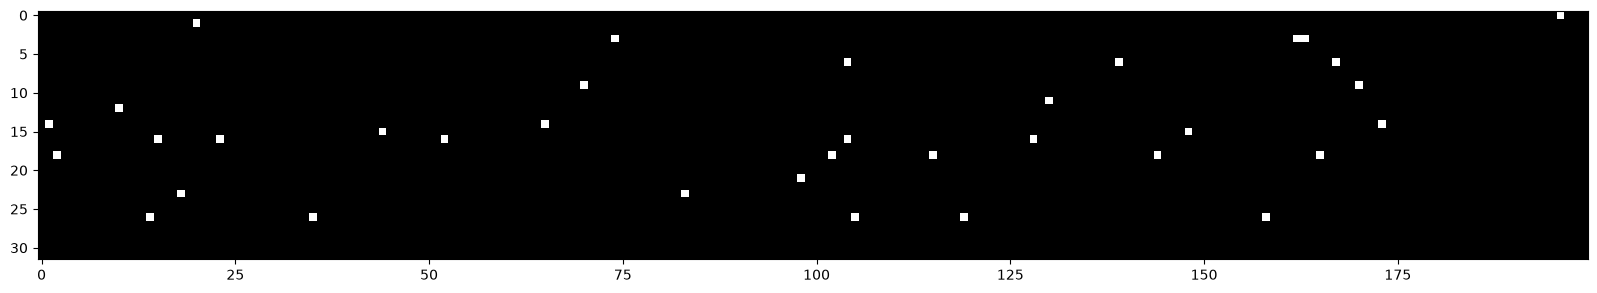

In [22]:
# verify hidden layer with different weight initialization constnat 
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest')

(array([3.600000e+01, 1.000000e+02, 1.630000e+02, 7.070000e+02,
        1.964000e+03, 5.372000e+03, 1.158100e+04, 1.891800e+04,
        2.995100e+04, 4.669300e+04, 9.203700e+04, 1.229460e+05,
        1.887800e+05, 3.540430e+05, 4.895930e+05, 7.028560e+05,
        1.016710e+06, 1.371900e+06, 1.854875e+06, 1.980953e+06,
        2.419087e+06, 2.682040e+06, 3.102188e+06, 3.082658e+06,
        3.008629e+06, 2.804603e+06, 2.347227e+06, 2.225877e+06,
        1.843448e+06, 1.321341e+06, 1.138828e+06, 7.487590e+05,
        5.766060e+05, 3.285040e+05, 2.238730e+05, 1.309110e+05,
        8.960600e+04, 6.078200e+04, 5.788400e+04, 1.770400e+04,
        7.740000e+03, 6.467000e+03, 6.915000e+03, 1.447000e+03,
        9.240000e+02, 4.930000e+02, 1.490000e+02, 5.800000e+01,
        5.900000e+01, 1.500000e+01]),
 array([-1.5622474 , -1.49518619, -1.42812498, -1.36106377, -1.29400256,
        -1.22694135, -1.15988014, -1.09281893, -1.02575772, -0.95869651,
        -0.8916353 , -0.82457409, -0.75751288, -

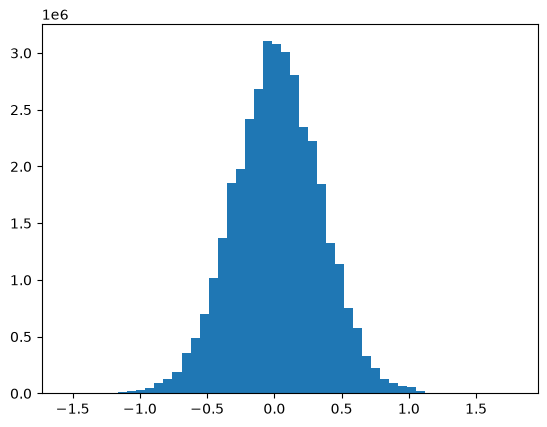

In [23]:
plt.hist(hpreact.view(-1).tolist(),50)

torch.Size([1000, 200])
w mean and std:  tensor(0.0114) tensor(0.9781)
x mean and std:  tensor(-0.0050) tensor(1.0011)
y mean and std:  tensor(0.0020) tensor(3.0915)


(array([7.05824474e-06, 0.00000000e+00, 1.41164895e-05, 7.05824474e-06,
        4.23494684e-05, 6.35242026e-05, 7.76406921e-05, 1.62339629e-04,
        3.67028726e-04, 7.34057452e-04, 9.45804795e-04, 1.77867767e-03,
        2.95740454e-03, 4.66549977e-03, 7.34057452e-03, 1.12790751e-02,
        1.74338645e-02, 2.54873217e-02, 3.64981835e-02, 5.16169438e-02,
        6.95660601e-02, 9.01831930e-02, 1.11089714e-01, 1.26406105e-01,
        1.37974568e-01, 1.38595694e-01, 1.29554082e-01, 1.12614295e-01,
        9.24065401e-02, 7.23258338e-02, 5.35014951e-02, 3.84674338e-02,
        2.73154071e-02, 1.75256217e-02, 1.16602203e-02, 8.03228251e-03,
        5.01841201e-03, 3.16915189e-03, 2.04689097e-03, 1.10108618e-03,
        6.35242026e-04, 3.95261705e-04, 2.39980321e-04, 2.25863832e-04,
        4.23494684e-05, 2.11747342e-05, 2.82329789e-05, 7.05824474e-06,
        7.05824474e-06, 1.41164895e-05]),
 array([-17.75423431, -17.0458429 , -16.33745148, -15.62906006,
        -14.92066864, -14.2122

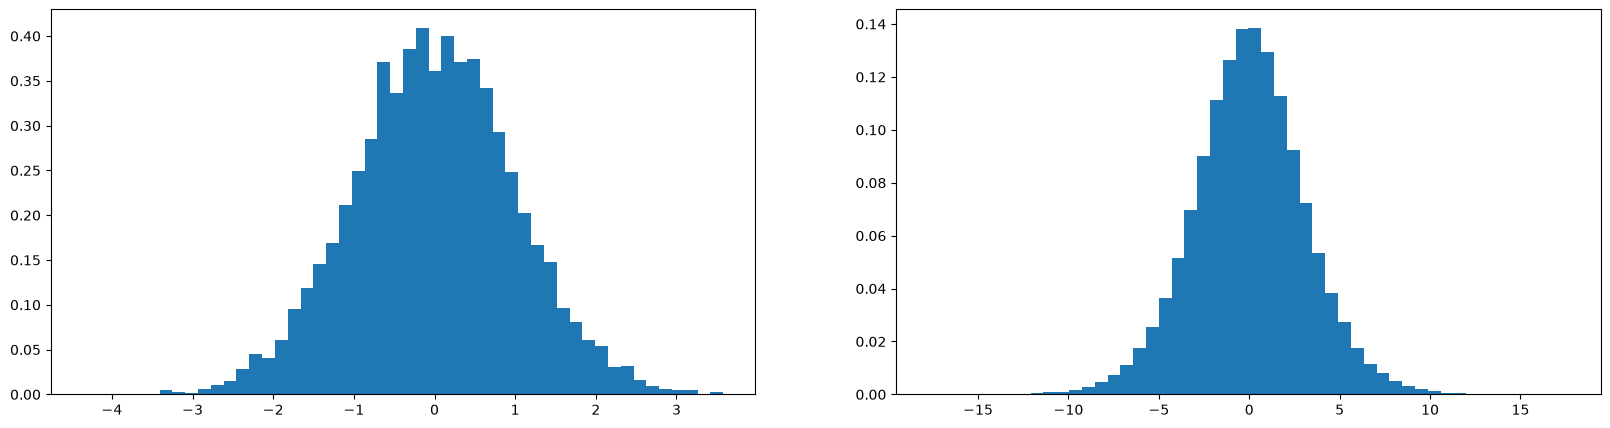

In [24]:
# Example: drawing a combination of gaussian
# when i draw x and w from gaussian

x=torch.randn(1000,10)
w=torch.randn(10,200)
y=x@w
print(y.shape)
print("w mean and std: ",w.mean(),w.std())
print("x mean and std: ",x.mean(),x.std())
print("y mean and std: ",y.mean(),y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True)

(array([180., 155., 189., 192., 181., 134., 148., 153., 132., 132., 125.,
        104., 124., 117., 108., 103., 103.,  94., 105.,  96., 100.,  82.,
        117.,  99., 104., 111.,  95., 110., 103., 117., 104.,  96., 131.,
         91., 101.,  97., 108., 100., 141., 138., 144., 121., 135., 145.,
        160., 143., 192., 189., 200., 151.]),
 array([-9.96078193e-01, -9.56214033e-01, -9.16349874e-01, -8.76485714e-01,
        -8.36621554e-01, -7.96757394e-01, -7.56893234e-01, -7.17029074e-01,
        -6.77164915e-01, -6.37300755e-01, -5.97436595e-01, -5.57572435e-01,
        -5.17708275e-01, -4.77844115e-01, -4.37979956e-01, -3.98115796e-01,
        -3.58251636e-01, -3.18387476e-01, -2.78523316e-01, -2.38659157e-01,
        -1.98794997e-01, -1.58930837e-01, -1.19066677e-01, -7.92025173e-02,
        -3.93383574e-02,  5.25802374e-04,  4.03899622e-02,  8.02541220e-02,
         1.20118282e-01,  1.59982442e-01,  1.99846601e-01,  2.39710761e-01,
         2.79574921e-01,  3.19439081e-01,  3.59303

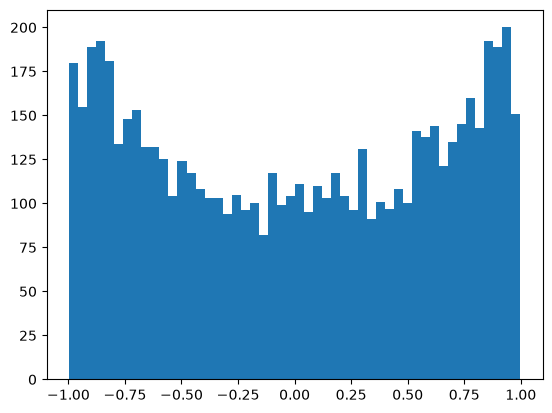

In [25]:
plt.hist(h.view(-1).tolist(),50)

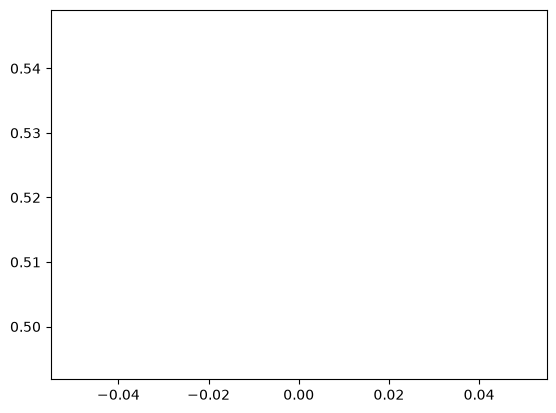

In [26]:
# correctly initialized neural nets dont have the 
# hockey stick pattern, because logits are normalized

plt.plot(lossi)

In [27]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [28]:
# now this is the correct comparison: full-dataset stats (bnmean) vs the EMA (bnmean_running)
# (bnmeani in the earlier cell was just one random 32-example minibatch's mean, not the
# population mean, so comparing it to bnmean_running was comparing noise to a smoothed estimate)
print('bnmean (full train set):', bnmean[0, :10])
print('bnmean_running:         ', bnmean_running[0, :10])
print('max abs diff:', (bnmean - bnmean_running).abs().max().item())

bnmean (full train set): tensor([-0.0959, -0.0311, -0.1922,  0.1398,  0.1446,  0.1200,  0.2327, -0.1451,
        -0.0959,  0.0739])
bnmean_running:          tensor([-1.4635e-04, -3.7081e-05, -1.6111e-04,  2.1921e-04,  9.5363e-05,
         8.6188e-05,  1.9562e-04, -1.5560e-04, -1.0547e-04,  1.4391e-04])
max abs diff: 0.2945798337459564


In [29]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.279045820236206
val 3.2790284156799316


In [30]:
'''

## loss log

### original:
train 2.449028968811035
val 2.5082149505615234

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.162630319595337
val 2.225909948348999

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491
'''

'\n\n## loss log\n\n### original:\ntrain 2.449028968811035\nval 2.5082149505615234\n\n### fix softmax confidently wrong:\ntrain 2.07\nval   2.13\n\n### fix tanh layer too saturated at init:\ntrain 2.162630319595337\nval 2.225909948348999\n\n### use semi-principled "kaiming init" instead of hacky init:\ntrain 2.0376641750335693\nval   2.106989622116089\n\n### add batch norm layer\ntrain 2.0668270587921143\nval 2.104844808578491\n'

tensor(0.0026) tensor(0.9936)
tensor(0.0078) tensor(3.1509)


(array([1.38193155e-05, 6.90965777e-06, 6.90965777e-06, 5.52772622e-05,
        6.21869200e-05, 1.03644867e-04, 2.48747680e-04, 4.42218098e-04,
        5.45862964e-04, 8.98255511e-04, 1.81723999e-03, 2.97115284e-03,
        4.53273550e-03, 7.82173260e-03, 1.14493029e-02, 1.80411164e-02,
        2.60839581e-02, 3.77958280e-02, 5.29832558e-02, 7.06719797e-02,
        9.08965480e-02, 1.09497347e-01, 1.25638307e-01, 1.35470750e-01,
        1.35111448e-01, 1.24505123e-01, 1.08695826e-01, 8.86232706e-02,
        6.88823784e-02, 5.07445267e-02, 3.57782080e-02, 2.52686185e-02,
        1.65071724e-02, 1.12972905e-02, 7.10312819e-03, 4.24943953e-03,
        2.81914037e-03, 1.79651102e-03, 1.00881004e-03, 6.14959542e-04,
        3.52392546e-04, 2.34928364e-04, 1.58922129e-04, 5.52772622e-05,
        2.07289733e-05, 1.38193155e-05, 1.38193155e-05, 6.90965777e-06,
        6.90965777e-06, 6.90965777e-06]),
 array([-17.31943893, -16.59581409, -15.87218925, -15.14856441,
        -14.42493958, -13.7013

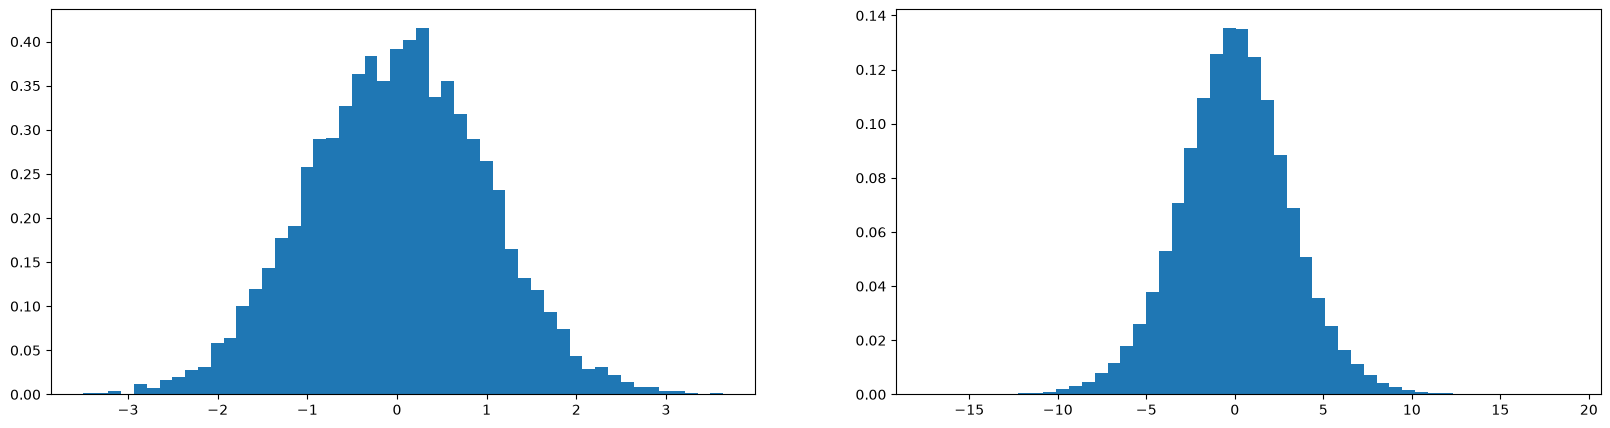

In [31]:
x = torch.randn(1000,10)
w = torch.randn(10,200) #/ w.shape[0] ** 0.5 # normalized gaussian for each input contriputing 
y = x@w
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True)

In [32]:
# SUMMARY + PYTORCHIFYING -----------

In [33]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [34]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.78%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.56%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.69%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%


C:\Users\jzcpo\AppData\Local\Temp\ipykernel_11508\1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

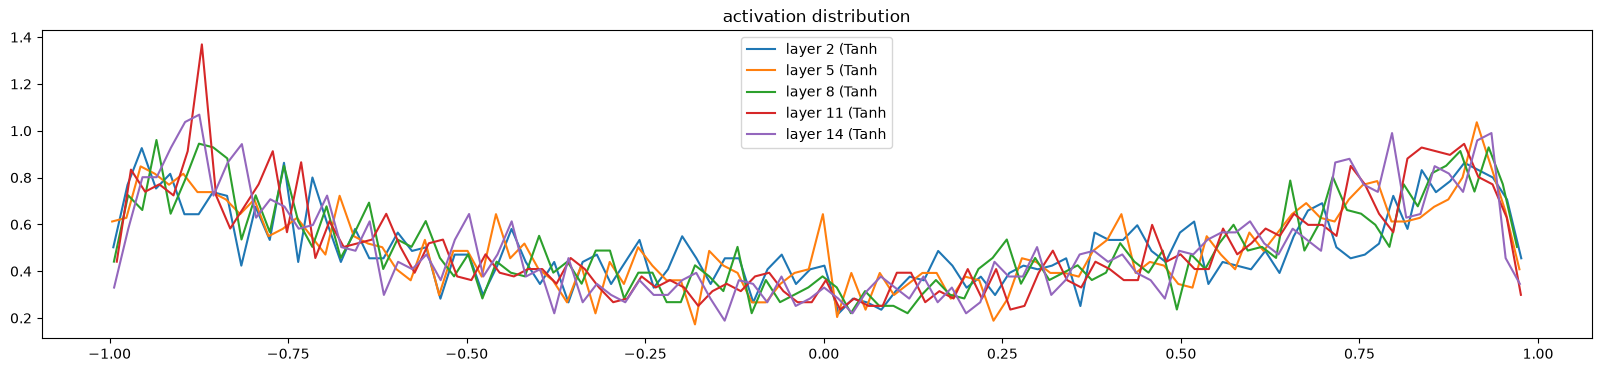

In [35]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 2.640701e-03
layer 5 (      Tanh): mean +0.000000, std 2.245583e-03
layer 8 (      Tanh): mean -0.000000, std 2.045741e-03
layer 11 (      Tanh): mean +0.000000, std 1.983133e-03
layer 14 (      Tanh): mean -0.000000, std 1.952381e-03


Text(0.5, 1.0, 'gradient distribution')

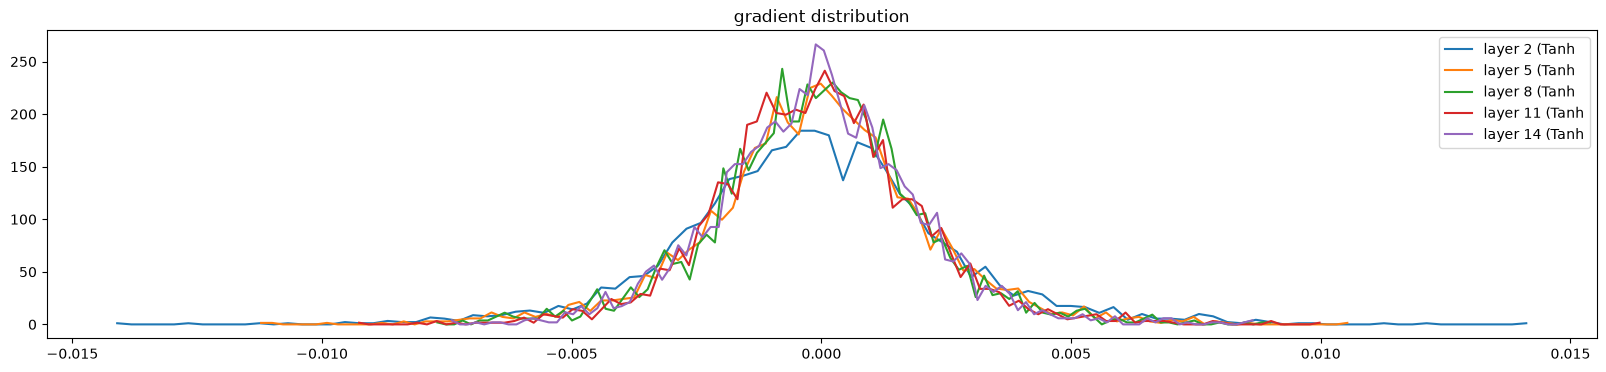

In [36]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 8.020530e-03 | grad:data ratio 8.012625e-03
weight  (30, 100) | mean +0.000246 | std 9.241068e-03 | grad:data ratio 4.881086e-02
weight (100, 100) | mean +0.000113 | std 7.132870e-03 | grad:data ratio 6.964611e-02
weight (100, 100) | mean -0.000086 | std 6.234298e-03 | grad:data ratio 6.073733e-02
weight (100, 100) | mean +0.000052 | std 5.742180e-03 | grad:data ratio 5.631475e-02
weight (100, 100) | mean +0.000032 | std 5.672203e-03 | grad:data ratio 5.570124e-02
weight  (100, 27) | mean -0.000082 | std 1.209415e-02 | grad:data ratio 1.160105e-01


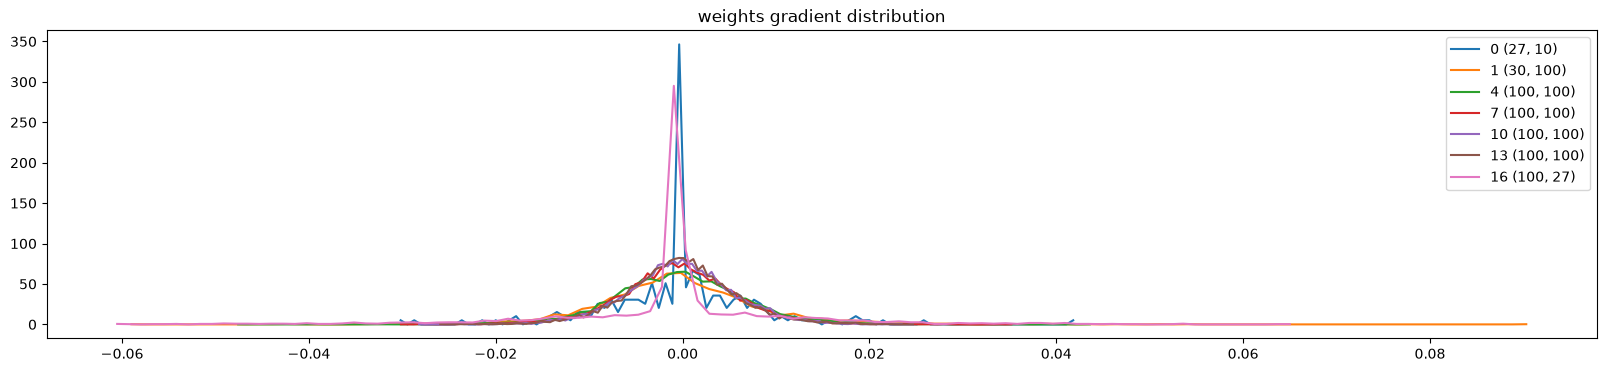

In [37]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

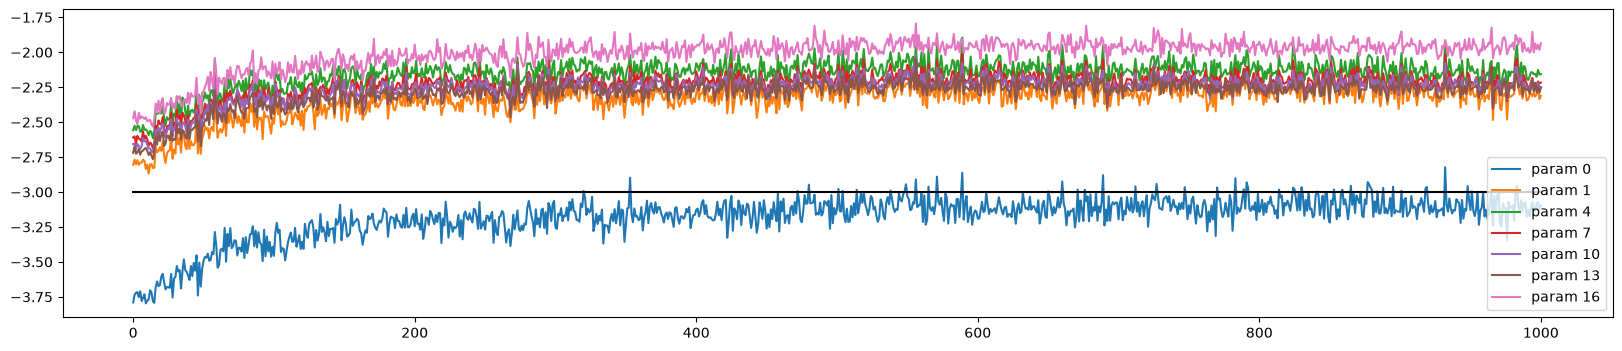

In [38]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [39]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.4002976417541504
val 2.3982467651367188


In [40]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carpah.
qarlileif.
jmrix.
thty.
sacansa.
jazhnte.
dpn.
arciigqeiunellaia.
chriiv.
kalein.
dhlm.
join.
qhinn.
sroin.
arian.
quiqaelogiearyxix.
kaeklinsan.
ed.
ecoia.
gtleley.


In [41]:
# DONE; BONUS content below, not covered in video

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

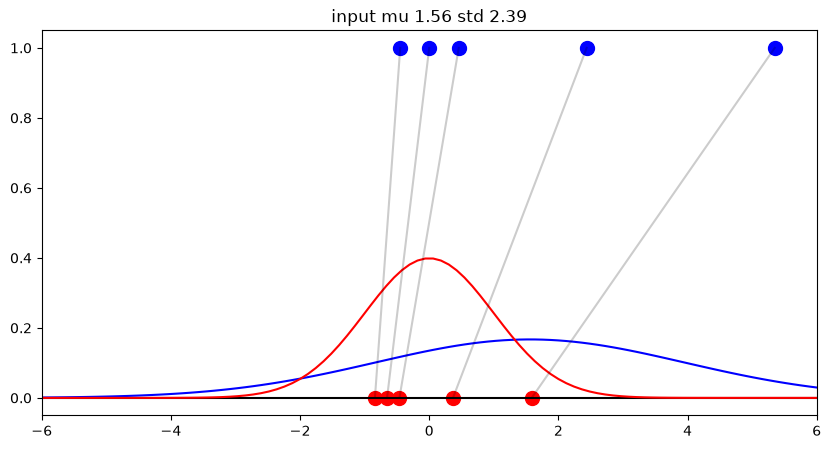

In [42]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


In [43]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [44]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
